# Mixture Model: Behavioral Subtypes in 5-Parameter Space

Data-driven clustering of people in {k, z, β, α, ρ} space.

**Key question:** Do people cluster into coupled (diagonal: choice and vigor aligned) vs decoupled (off-diagonal: choice and vigor dissociated) subtypes? Does β gate the coupling?

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis as FA
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

ROOT = Path("../../")
DATA = ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260317_094210"
RESULTS = ROOT / "results"
STAT_DIR = RESULTS / "stats"
FIG_DIR = RESULTS / "figs"

print("Setup complete")

Setup complete


## 1. Load and prepare data

In [2]:
# 5 behavioral params
params = pd.read_csv(STAT_DIR / "vigor_hbm_posteriors.csv")

# Psychiatric battery → 3 factors
psych = pd.read_csv(DATA / "psych.csv")
efa_cols = [
    "DASS21_Stress", "DASS21_Anxiety", "DASS21_Depression",
    "AMI_Behavioural", "AMI_Social", "AMI_Emotional",
    "MFIS_Physical", "MFIS_Cognitive", "MFIS_Psychosocial",
    "OASIS_Total", "PHQ9_Total", "STICSA_Total",
    "STAI_State", "STAI_Trait",
]

def varimax_rotation(L, max_iter=100, tol=1e-6):
    L = L.copy(); p, k = L.shape; rot = np.eye(k)
    for _ in range(max_iter):
        old = rot.copy()
        for i in range(k):
            for j in range(i+1, k):
                u = L[:,i]**2 - L[:,j]**2; v = 2*L[:,i]*L[:,j]
                num = 2*p*(u*v).sum() - 2*u.sum()*v.sum()
                den = p*((u**2-v**2).sum()) - (u.sum()**2-v.sum()**2)
                ang = 0.25*np.arctan2(num,den); r = np.eye(k)
                r[i,i]=np.cos(ang); r[j,j]=np.cos(ang)
                r[i,j]=-np.sin(ang); r[j,i]=np.sin(ang)
                L = L@r; rot = rot@r
        if np.max(np.abs(rot-old)) < tol: break
    return L, rot

psych_valid = psych.dropna(subset=efa_cols)
X_psych_z = StandardScaler().fit_transform(psych_valid[efa_cols])
fa3 = FA(n_components=3, random_state=42); fa3.fit(X_psych_z)
_, rot_mat = varimax_rotation(fa3.components_.T)
scores_3f = fa3.transform(X_psych_z) @ rot_mat
psych_factors = pd.DataFrame(scores_3f, columns=["Distress","Fatigue","Apathy"], index=psych_valid.index)
psych_factors["subj"] = psych_valid["subj"].values

# Behavior data
behavior = pd.read_csv(DATA / "behavior.csv")

# Trial events for attack info and rewards
import pickle
trials_raw = pickle.load(open(ROOT / "data/exploratory_350/processed/stage2_trial_processing_20260317_094210/processed_trials.pkl", "rb"))
subj_map = pd.read_csv(ROOT / "data/exploratory_350/processed/vigor_prep/subject_mapping.csv")
trials_raw = trials_raw.merge(subj_map, on="participantID", how="inner")

# CRITICAL: outcome=1 means CAPTURED, outcome=0 means ESCAPED
# Escape rate = 1 - mean(outcome) on attack trials
attack_trials = trials_raw[trials_raw["isAttackTrial"] == 1]
escape_rate = (1 - attack_trials.groupby("subj")["outcome"].mean()).rename("escape_rate").reset_index()

# Earnings
earnings = trials_raw.groupby("subj")["trialReward"].sum().rename("earnings").reset_index()

# Choice rate
choice_rate = behavior.groupby("subj")["choice"].mean().rename("choice_rate").reset_index()

# Probe affect
feelings = pd.read_csv(DATA / "feelings.csv")
anx = feelings[feelings["questionLabel"]=="anxiety"]
conf = feelings[feelings["questionLabel"]=="confidence"]
anx_mean = anx.groupby("subj")["response"].mean().rename("anx_mean")
conf_mean = conf.groupby("subj")["response"].mean().rename("conf_mean")
affect = pd.concat([anx_mean, conf_mean], axis=1).reset_index()

# Merge all
df = params[["subj","alpha_bayes","rho_bayes","k","z","beta"]].copy()
df = df.merge(psych_factors, on="subj", how="inner")
df = df.merge(affect, on="subj", how="inner")
df = df.merge(escape_rate, on="subj", how="left")
df = df.merge(earnings, on="subj", how="left")
df = df.merge(choice_rate, on="subj", how="left")
df = df.dropna()

print(f"N = {len(df)}")
print(f"Escape rate: mean={df['escape_rate'].mean():.3f}, range=[{df['escape_rate'].min():.3f}, {df['escape_rate'].max():.3f}]")

# Standardize 5 params for clustering
param_cols = ["k", "z", "beta", "alpha_bayes", "rho_bayes"]
param_labels = ["k", "z", "β", "α", "ρ"]
scaler = StandardScaler()
X_clust = scaler.fit_transform(df[param_cols])

N = 291
Escape rate: mean=0.384, range=[0.000, 0.902]


## 2. Model selection: how many clusters?

  k=2: BIC=3755, AIC=3604, silhouette=0.247


  k=3: BIC=3610, AIC=3382, silhouette=0.188


  k=4: BIC=3545, AIC=3240, silhouette=0.105


  k=5: BIC=3560, AIC=3178, silhouette=0.119


  k=6: BIC=3557, AIC=3098, silhouette=0.072


  k=7: BIC=3602, AIC=3066, silhouette=0.080


  k=8: BIC=3672, AIC=3058, silhouette=0.098


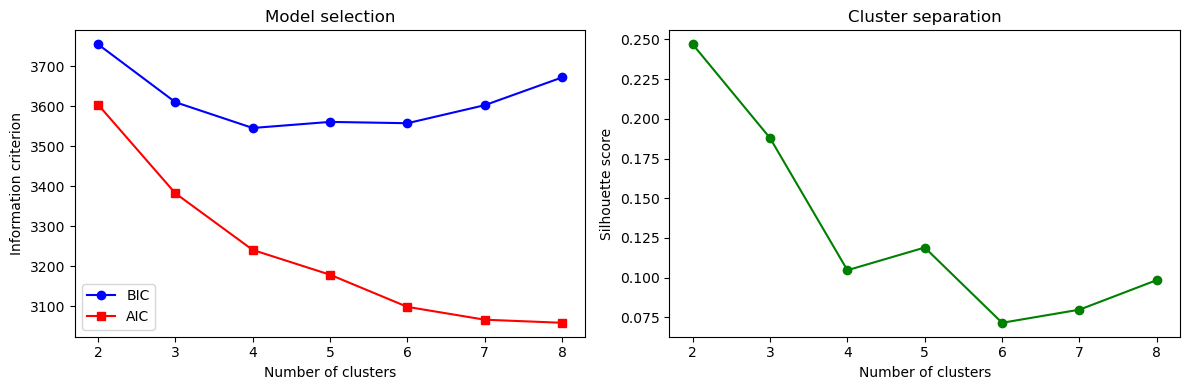


Best by BIC: 4, by silhouette: 2


In [3]:
# BIC and silhouette for 2-8 clusters
ks = range(2, 9)
bics = []
aics = []
silhouettes = []

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          n_init=20, random_state=42)
    gmm.fit(X_clust)
    bics.append(gmm.bic(X_clust))
    aics.append(gmm.aic(X_clust))
    labels = gmm.predict(X_clust)
    silhouettes.append(silhouette_score(X_clust, labels))
    print(f"  k={k}: BIC={bics[-1]:.0f}, AIC={aics[-1]:.0f}, silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), bics, "bo-", label="BIC")
axes[0].plot(list(ks), aics, "rs-", label="AIC")
axes[0].set(xlabel="Number of clusters", ylabel="Information criterion",
            title="Model selection")
axes[0].legend()

axes[1].plot(list(ks), silhouettes, "go-")
axes[1].set(xlabel="Number of clusters", ylabel="Silhouette score",
            title="Cluster separation")

plt.tight_layout()
plt.savefig(FIG_DIR / "gmm_model_selection.png", dpi=150, bbox_inches="tight")
plt.show()

best_k_bic = list(ks)[np.argmin(bics)]
best_k_sil = list(ks)[np.argmax(silhouettes)]
print(f"\nBest by BIC: {best_k_bic}, by silhouette: {best_k_sil}")

## 3. Fit selected GMM and characterize clusters

In [4]:
# Fit with BIC-optimal k AND with k=4 (to compare with quadrants)
results_by_k = {}
for n_clust in sorted(set([best_k_bic, 4])):
    print(f"\n{'='*60}")
    print(f"GMM with k={n_clust}")
    print(f"{'='*60}")
    
    gmm = GaussianMixture(n_components=n_clust, covariance_type="full",
                          n_init=20, random_state=42)
    gmm.fit(X_clust)
    col = f"cluster_{n_clust}"
    df[col] = gmm.predict(X_clust)
    df[f"{col}_prob"] = gmm.predict_proba(X_clust).max(axis=1)
    results_by_k[n_clust] = gmm
    
    # Cluster sizes
    print(f"\nCluster sizes:")
    print(df[col].value_counts().sort_index())
    
    # Parameter profiles per cluster
    print(f"\nParameter profiles (raw means):")
    profile = df.groupby(col)[param_cols].mean()
    profile.columns = param_labels
    print(profile.round(3))
    
    # Outcomes per cluster
    outcome_cols = ["escape_rate", "earnings", "choice_rate",
                    "anx_mean", "conf_mean", "Distress", "Fatigue", "Apathy"]
    print(f"\nOutcome profiles:")
    outcome_profile = df.groupby(col)[outcome_cols].mean()
    print(outcome_profile.round(3))
    
    # ANOVA for each outcome
    print(f"\nANOVA (cluster -> outcome):")
    for oc in outcome_cols:
        groups = [g[oc].values for _, g in df.groupby(col)]
        F, p = stats.f_oneway(*groups)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {oc:15s}: F={F:7.2f}, p={p:.4f}{sig}")


GMM with k=4



Cluster sizes:
cluster_4
0     90
1      8
2    113
3     80
Name: count, dtype: int64

Parameter profiles (raw means):
               k      z      β      α      ρ
cluster_4                                   
0          1.137  0.314  2.206  0.603  0.536
1          3.998  0.430  9.638  0.460  0.543
2          1.635  0.272  0.481  0.427  0.532
3          3.069  0.592  1.092  0.560  0.502

Outcome profiles:
           escape_rate  earnings  choice_rate  anx_mean  conf_mean  Distress  \
cluster_4                                                                      
0                0.473    43.211        0.435     4.265      3.117    -0.028   
1                0.407   -26.000        0.031     4.778      2.708     0.162   
2                0.255   -20.726        0.583     4.421      3.488     0.002   
3                0.462     7.650        0.256     4.476      2.825     0.012   

           Fatigue  Apathy  
cluster_4                   
0           -0.132  -0.157  
1           -0.241  -0

## 4. Visualize clusters in param space

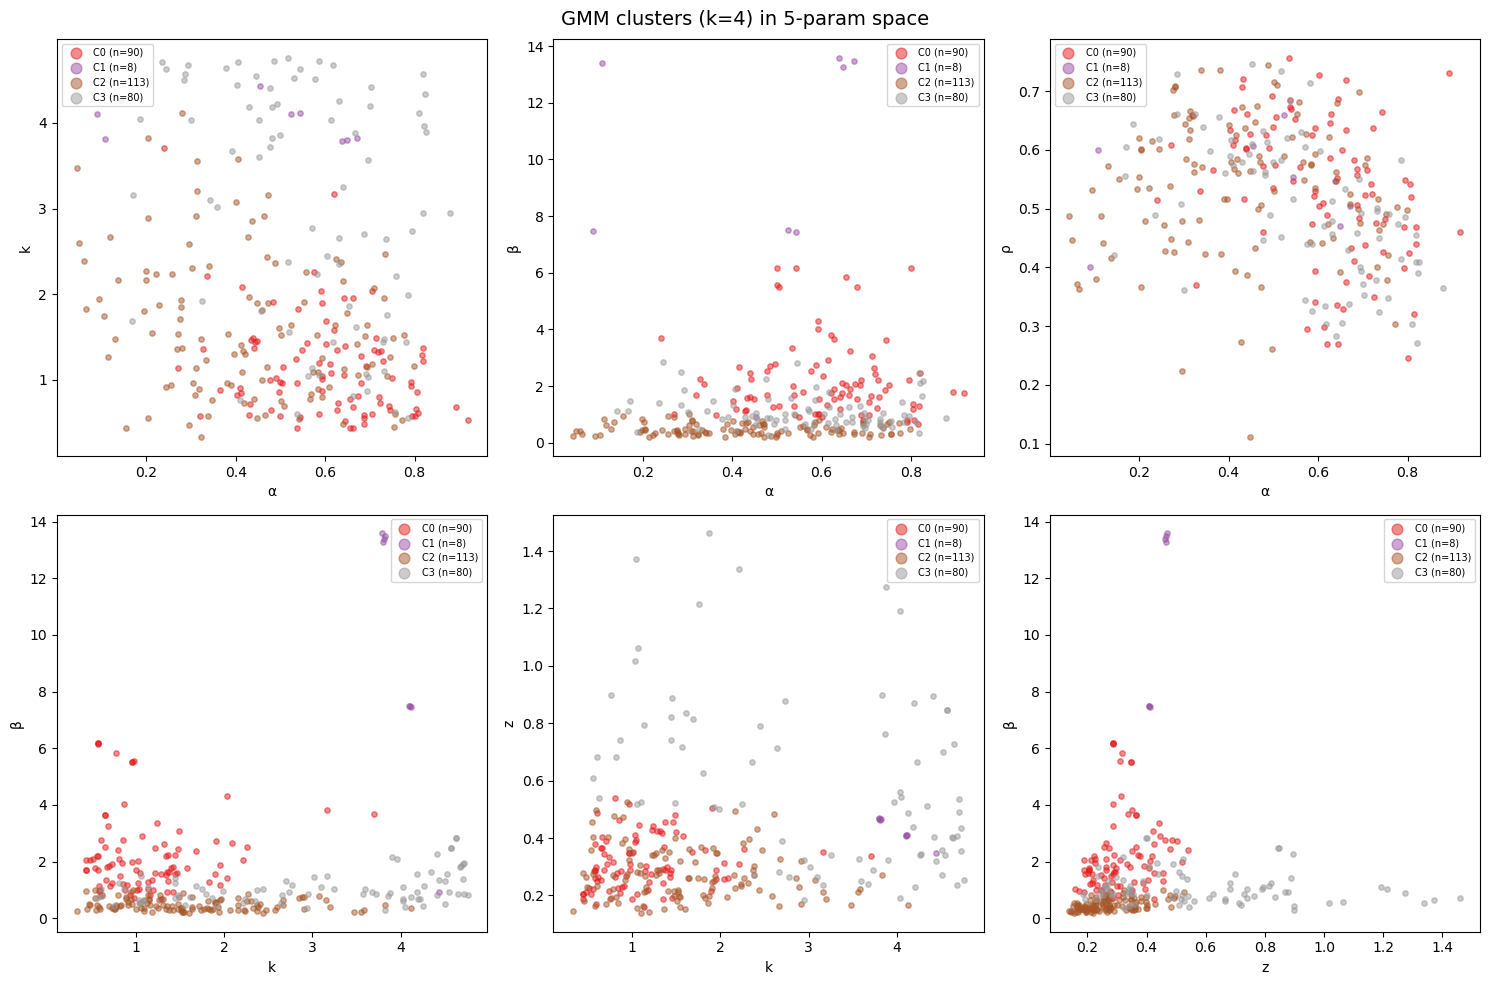

In [5]:
# Visualize with 4 clusters (for coupled/decoupled comparison)
n_clust = 4
clust_col = f"cluster_{n_clust}"

# Key 2D projections
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pairs = [("alpha_bayes","k"), ("alpha_bayes","beta"), ("alpha_bayes","rho_bayes"),
         ("k","beta"), ("k","z"), ("z","beta")]
pair_labels = [("α","k"), ("α","β"), ("α","ρ"),
               ("k","β"), ("k","z"), ("z","β")]

colors = plt.cm.Set1(np.linspace(0, 1, n_clust))

for idx, ((x, y), (xl, yl)) in enumerate(zip(pairs, pair_labels)):
    ax = axes.flat[idx]
    for c in range(n_clust):
        mask = df[clust_col] == c
        ax.scatter(df.loc[mask, x], df.loc[mask, y],
                   c=[colors[c]], s=15, alpha=0.5, label=f"C{c} (n={mask.sum()})")
    ax.set(xlabel=xl, ylabel=yl)
    ax.legend(fontsize=7, markerscale=2)

plt.suptitle(f"GMM clusters (k={n_clust}) in 5-param space", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "gmm_clusters_params.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Coupled vs decoupled analysis

In [6]:
# Per-subject choice-vigor coupling
# Compute choice-vigor correlation across trials for each subject
behavior_with_vigor = behavior.merge(
    params[["subj", "alpha_bayes"]], on="subj")

# Define coupling: do subjects on the diagonal (HH/LL) differ from off-diagonal (HL/LH)?
# Median split on choice and vigor
med_choice = df["choice_rate"].median()
med_alpha = df["alpha_bayes"].median()

df["quad"] = "--"
df.loc[(df["choice_rate"] >= med_choice) & (df["alpha_bayes"] >= med_alpha), "quad"] = "HH"
df.loc[(df["choice_rate"] >= med_choice) & (df["alpha_bayes"] < med_alpha), "quad"] = "HL"
df.loc[(df["choice_rate"] < med_choice) & (df["alpha_bayes"] >= med_alpha), "quad"] = "LH"
df.loc[(df["choice_rate"] < med_choice) & (df["alpha_bayes"] < med_alpha), "quad"] = "LL"

df["diagonal"] = df["quad"].isin(["HH", "LL"])
df["coupled"] = df["diagonal"].map({True: "Coupled (HH/LL)", False: "Decoupled (HL/LH)"})

print("Coupled vs Decoupled:")
print(df["coupled"].value_counts())

# Compare on all outcomes
print("\n=== Coupled vs Decoupled ===")
compare_cols = ["escape_rate", "earnings", "conf_mean", "anx_mean",
                "Distress", "Fatigue", "Apathy",
                "k", "z", "beta", "alpha_bayes", "rho_bayes"]

for col in compare_cols:
    coupled = df[df["diagonal"]][col]
    decoupled = df[~df["diagonal"]][col]
    t, p = stats.ttest_ind(coupled, decoupled)
    d = (coupled.mean() - decoupled.mean()) / np.sqrt((coupled.std()**2 + decoupled.std()**2) / 2)
    sig = "*" if p < 0.05 else ""
    print(f"  {col:15s}: coupled={coupled.mean():.3f}, decoupled={decoupled.mean():.3f}, d={d:+.3f}, p={p:.4f}{sig}")

# Quadrant-level comparison
print("\n=== Per-quadrant profiles ===")
quad_profile = df.groupby("quad")[["k","z","beta","alpha_bayes","rho_bayes",
                                    "escape_rate","earnings","conf_mean","anx_mean",
                                    "Distress","Fatigue","Apathy"]].mean()
quad_profile.columns = ["k","z","β","α","ρ","Escape","Earn","Conf","Anx","Distress","Fatigue","Apathy"]
print(quad_profile.round(3))
print(f"\nQuadrant sizes: {df['quad'].value_counts().to_dict()}")

Coupled vs Decoupled:
coupled
Decoupled (HL/LH)    155
Coupled (HH/LL)      136
Name: count, dtype: int64

=== Coupled vs Decoupled ===
  escape_rate    : coupled=0.390, decoupled=0.378, d=+0.050, p=0.6718
  earnings       : coupled=12.441, decoupled=1.671, d=+0.121, p=0.3029
  conf_mean      : coupled=3.194, decoupled=3.147, d=+0.035, p=0.7663
  anx_mean       : coupled=4.396, decoupled=4.399, d=-0.002, p=0.9843
  Distress       : coupled=-0.062, decoupled=0.055, d=-0.124, p=0.2937
  Fatigue        : coupled=-0.024, decoupled=0.021, d=-0.050, p=0.6744
  Apathy         : coupled=-0.024, decoupled=0.021, d=-0.053, p=0.6511
  k              : coupled=2.034, decoupled=1.858, d=+0.138, p=0.2361
  z              : coupled=0.378, decoupled=0.377, d=+0.006, p=0.9623
  beta           : coupled=1.402, decoupled=1.463, d=-0.032, p=0.7856
  alpha_bayes    : coupled=0.539, decoupled=0.501, d=+0.201, p=0.0879
  rho_bayes      : coupled=0.544, decoupled=0.509, d=+0.292, p=0.0142*

=== Per-quadrant p

In [7]:
# Do GMM clusters map onto the coupled/decoupled distinction?
clust_col_4 = "cluster_4"
print("GMM 4-cluster × quadrant crosstab:")
ct = pd.crosstab(df[clust_col_4], df["quad"])
print(ct)

print(f"\nGMM 4-cluster × coupled/decoupled:")
ct2 = pd.crosstab(df[clust_col_4], df["coupled"])
print(ct2)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct2)
print(f"\nChi-squared: {chi2:.1f}, df={dof}, p={p_chi:.4f}")

# Also show BIC-optimal clusters if different from 4
if best_k_bic != 4:
    clust_col_best = f"cluster_{best_k_bic}"
    print(f"\n\nGMM {best_k_bic}-cluster (BIC-optimal) × quadrant:")
    ct3 = pd.crosstab(df[clust_col_best], df["quad"])
    print(ct3)
    
    ct4 = pd.crosstab(df[clust_col_best], df["coupled"])
    print(f"\n{best_k_bic}-cluster × coupled/decoupled:")
    print(ct4)
    chi2b, p_chi_b, _, _ = stats.chi2_contingency(ct4)
    print(f"Chi-squared: {chi2b:.1f}, p={p_chi_b:.4f}")

GMM 4-cluster × quadrant crosstab:
quad       HH  HL  LH  LL
cluster_4                
0          31  14  30  15
1           0   0   4   4
2          34  65   2  12
3           9   4  36  31

GMM 4-cluster × coupled/decoupled:
coupled    Coupled (HH/LL)  Decoupled (HL/LH)
cluster_4                                    
0                       46                 44
1                        4                  4
2                       46                 67
3                       40                 40

Chi-squared: 2.7, df=3, p=0.4372


## 6. β as the gating parameter

β → coupling distance (|choice_z - α_z|): r=+0.053, p=0.3633
β → coupling product (choice_z × α_z):     r=+0.068, p=0.2492

All params → coupling product (positive = aligned):
  k: r=+0.094, p=0.1083
  z: r=-0.014, p=0.8085
  β: r=+0.068, p=0.2492
  α: r=+0.014, p=0.8075
  ρ: r=+0.114, p=0.0523

Joint model → coupling product: R²=0.030, p=1.16e-01
  k: β=+0.113, p=0.0706
  z: β=-0.036, p=0.5573
  β: β=+0.049, p=0.4114
  α: β=+0.069, p=0.2740
  ρ: β=+0.131, p=0.0310


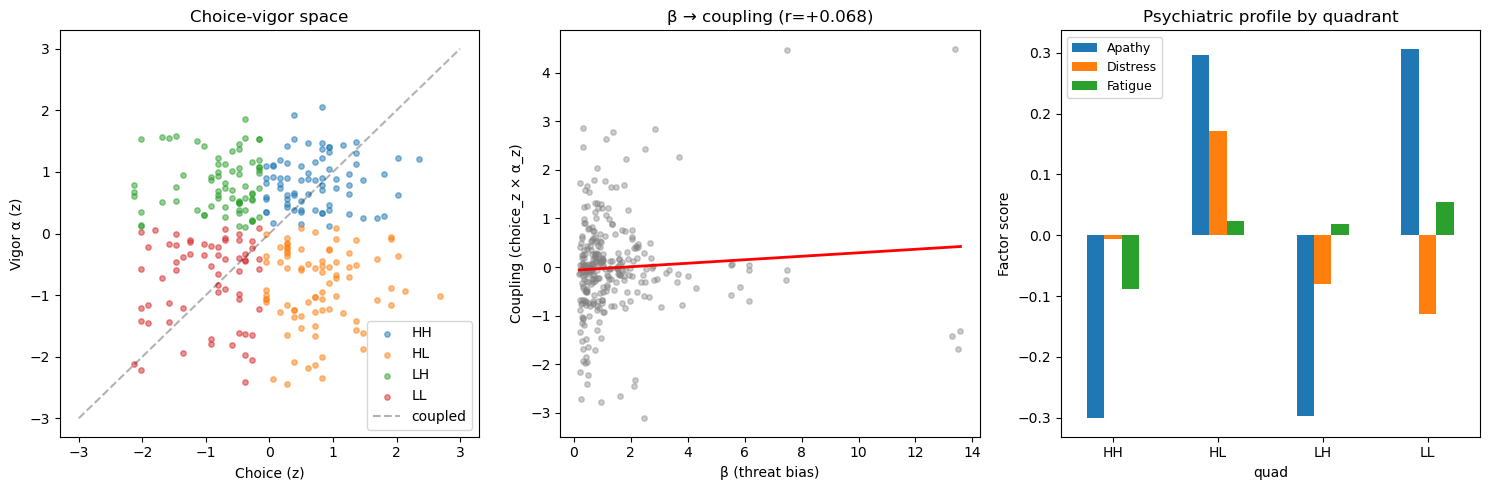

In [8]:
# Does β predict coupling strength?
# Coupling = alignment of choice and vigor (both high or both low)
# Continuous measure: |choice_z - alpha_z| (small = coupled, large = decoupled)
df["choice_z"] = (df["choice_rate"] - df["choice_rate"].mean()) / df["choice_rate"].std()
df["alpha_z"] = (df["alpha_bayes"] - df["alpha_bayes"].mean()) / df["alpha_bayes"].std()
df["coupling_dist"] = np.abs(df["choice_z"] - df["alpha_z"])  # 0 = perfectly coupled
df["coupling_product"] = df["choice_z"] * df["alpha_z"]  # positive = same direction

# β → coupling distance
r_dist, p_dist = stats.pearsonr(df["beta"], df["coupling_dist"])
r_prod, p_prod = stats.pearsonr(df["beta"], df["coupling_product"])
print(f"β → coupling distance (|choice_z - α_z|): r={r_dist:+.3f}, p={p_dist:.4f}")
print(f"β → coupling product (choice_z × α_z):     r={r_prod:+.3f}, p={p_prod:.4f}")

# All params → coupling product
print("\nAll params → coupling product (positive = aligned):")
for col, label in zip(param_cols, param_labels):
    r, p = stats.pearsonr(df[col], df["coupling_product"])
    sig = "*" if p < 0.05 else ""
    print(f"  {label}: r={r:+.3f}, p={p:.4f}{sig}")

# Multiple regression
X_reg = sm.add_constant(StandardScaler().fit_transform(df[param_cols]))
model = sm.OLS(df["coupling_product"].values, X_reg).fit()
print(f"\nJoint model → coupling product: R²={model.rsquared:.3f}, p={model.f_pvalue:.2e}")
for j, label in enumerate(param_labels):
    print(f"  {label}: β={model.params[j+1]:+.3f}, p={model.pvalues[j+1]:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
for q, color in zip(["HH","HL","LH","LL"], ["C0","C1","C2","C3"]):
    mask = df["quad"] == q
    ax.scatter(df.loc[mask, "choice_z"], df.loc[mask, "alpha_z"],
              s=15, alpha=0.5, label=q, c=color)
ax.plot([-3,3], [-3,3], "k--", alpha=0.3, label="coupled")
ax.set(xlabel="Choice (z)", ylabel="Vigor α (z)", title="Choice-vigor space")
ax.legend()

ax = axes[1]
ax.scatter(df["beta"], df["coupling_product"], s=15, alpha=0.4, c="gray")
z = np.polyfit(df["beta"], df["coupling_product"], 1)
x_line = np.linspace(df["beta"].min(), df["beta"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "r-", lw=2)
ax.set(xlabel="β (threat bias)", ylabel="Coupling (choice_z × α_z)",
       title=f"β → coupling (r={r_prod:+.3f})")

ax = axes[2]
quad_means = df.groupby("quad")[["Apathy","Distress","Fatigue"]].mean()
quad_means.plot(kind="bar", ax=ax, rot=0)
ax.set(ylabel="Factor score", title="Psychiatric profile by quadrant")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "gmm_coupling_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save

In [9]:
# Save cluster assignments and coupling measures
save_cols = ["subj"] + param_cols + ["quad", "diagonal", "coupling_product", "coupling_dist"]
save_cols += [c for c in df.columns if c.startswith("cluster_")]
df[save_cols].to_csv(STAT_DIR / "behavioral_subtypes.csv", index=False)
print(f"Saved: behavioral_subtypes.csv")
print(f"Columns: {save_cols}")

Saved: behavioral_subtypes.csv
Columns: ['subj', 'k', 'z', 'beta', 'alpha_bayes', 'rho_bayes', 'quad', 'diagonal', 'coupling_product', 'coupling_dist', 'cluster_4', 'cluster_4_prob']
